# ***Bag of Words* e TF-IDF**

Autores: Alex Koji, Camilla Fonseca, Vitoria Rodrigues (adaptado)

## ***Feature extraction***

Para usarmos um modelo estatístico ou de deep learning em NLP, precisamos de variáveis, que são informações mensuráveis acerca de algum fenômeno, ou uma forma estruturada de armazenar informações.

Porém, textos são um tipo de dado não estruturado (não organizado de uma maneira pré-definida, fixa), sendo difícil para o computador entendê-los e analisá-los.

Por isso, realizamos a chamada *feature extraction*, ou seja, transformamos o texto em uma informação numérica de modo que seja possível utilizá-lo para alimentar um modelo. Uma das maneiras mais populares e simples de fazer isso é usando a técnica conhecida como *Bag of Words (BoW)*.

## ***Bag of Words (BOW)***

*Bag of Words* é uma forma de representar o texto de acordo com a ocorrência das palavras nele. É traduzido literalmente para “saco de palavras” e recebe esse nome porque não leva em conta a ordem ou a estrutura das palavras no texto, apenas se ela aparece ou a frequência com que aparece nele.

Por exemplo, se a palavra `MODELAGEM` aparece muito num texto, ela se torna mais central e importante para a máquina. Portanto, `BoW` pode ser um ótimo método para determinar as palavras significativas de um texto com base no número de vezes que ela é usada.

Basicamente, para gerar um modelo de *Bag of Words* precisamos realizar três passos:

1. Selecionar os dados;

2. Gerar o vocabulário;

3. Formar vetores a partir do documento.


**Selecionar os dados**

Aqui iremos selecionar os dados que serão usados (no nosso caso, o texto) e prepará-lo de forma que a máquina consiga processá-lo da melhor forma possível.

Neste exemplo iremos utilizar o poema “No Meio do Caminho” do poeta Carlos Drummond de Andrade:
```
“No meio do caminho tinha uma pedra
tinha uma pedra no meio do caminho
tinha uma pedra
no meio do caminho tinha uma pedra.

Nunca me esquecerei desse acontecimento
na vida de minhas retinas tão fatigadas.
Nunca me esquecerei que no meio do caminho
tinha uma pedra
tinha uma pedra no meio do caminho
no meio do caminho tinha uma pedra.”
```

Vamos iniciar colocando nosso texto em um objeto chamado `texto`.



In [ ]:
texto = '''
        No meio do caminho tinha uma pedra
        tinha uma pedra no meio do caminho
        tinha uma pedra
        no meio do caminho tinha uma pedra.
        Nunca me esquecerei desse acontecimento
        na vida de minhas retinas tão fatigadas.
        Nunca me esquecerei que no meio do caminho
        tinha uma pedra
        tinha uma pedra no meio do caminho
        no meio do caminho tinha uma pedra.
        '''

Vamos fazer o pré-processamento, essencial quando queremos trabalhar com textos, principalmente quando queremos aplicar um modelo de predição ou outros métodos estatísticos. Serão realizadas as seguintes etapas:

- Colocar todas as letras em minúsculo.
- Selecionar apenas letras com REGEX.
- Juntar os *tokens* em um texto, já que, ao usar o método `findall` do regex, nosso texto é dividido em tokens, ou seja, cada palavra vira uma string individual em uma lista

**Colocar todas as letras como minúsculas**

Colocar todas as letras em minúsculo para evitar a diferenciação entre minúsculas e maiúsculas.

**Selecionando apenas letras com REGEX**

Esse passo é fundamental porque, para a máquina, a pontuação de um texto não importa e muitas vezes ela entende a pontuação como também sendo uma palavra. E para nossa análise com `BoW`, tão pouco importam os números.

Nesse caso, vamos utilizar a biblioteca `re` e o método `findall`.

**Juntando os tokens**

Já que o `findall` nos retorna todas as palavras como strings dentro de uma lista (*tokens*), vamos juntá-las com o método `join()`.

Dessa forma nosso texto volta a ser um texto contíguo novamente

In [ ]:
import re

# deixa todas as letras minúsculas
texto_min = texto.lower()

# seleciona palavras úteis apenas
apenas_letras = re.findall(r'[a-zéóáêâãõç]+', texto_min)

# junta o texto, já que o .findall separa em tokens
novo_texto = " ".join(apenas_letras)

print(novo_texto)

no meio do caminho tinha uma pedra tinha uma pedra no meio do caminho tinha uma pedra no meio do caminho tinha uma pedra nunca me esquecerei desse acontecimento na vida de minhas retinas tão fatigadas nunca me esquecerei que no meio do caminho tinha uma pedra tinha uma pedra no meio do caminho no meio do caminho tinha uma pedra


**Gerando o vocabulário**

Para gerar o vocabulário, que nada mais é que a coleção de todas as palavras que ocorrem em um texto, vamos passar por elas, seguindo o algoritmo a seguir.

- Separar nosso texto em *tokens*;
- Criar uma lista para guardarmos o vocabulário;
- Fazer um *loop* para percorrer o texto inteiro;
- Criar uma condição para verificar se a palavra está na lista (faremos isso para garantir que nosso vocabulário tenha apenas ocorrências únicas, sem repetições de palavras);
- Caso não esteja, ela é adicionada.

In [ ]:
from nltk import word_tokenize
import nltk

nltk.download('punkt_tab')

tokens = word_tokenize(novo_texto)


Vocab = []
for token in tokens:
    if token not in Vocab:
        Vocab.append(token)

print(Vocab,"\n",len(Vocab))

['no', 'meio', 'do', 'caminho', 'tinha', 'uma', 'pedra', 'nunca', 'me', 'esquecerei', 'desse', 'acontecimento', 'na', 'vida', 'de', 'minhas', 'retinas', 'tão', 'fatigadas', 'que'] 
 20


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


**Formando vetores**

Como o vocabulário tem um número fixo de palavras, podemos usar uma representação de tamanho fixo equivalente a esse número, neste caso, um vetor, com cada elemento desse vetor correspondendo a uma palavra do vocabulário.

Há diversas formas de preencher nosso vetor com números para representar um documento, por exemplo, usar a contagem de vezes em que a palavra aparece nele. Mas a maneira mais básica de fazer isso é atribuindo o valor `1` se a palavra aparece e `0` se não.

Podemos pensar nesse processo como uma tabulação do documento, veja o exemplo com os versos “Nunca me esquecerei que no meio do caminho/tinha uma pedra/tinha uma pedra no meio do caminho/no meio do caminho tinha uma pedra.”:



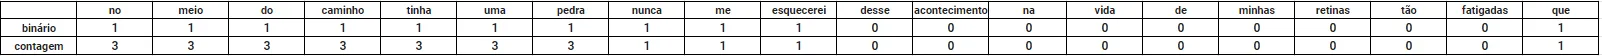

Para realizar a codificação binária, faremos o seguinte:

- Criar uma lista que representa o vetor;
- Fazer um loop para percorrer todas as palavras do vocabulário;
- Se a palavra estiver no documento, adicionar `1` à lista; caso contrário, adicionar `0`;
- Transformar a lista final em um array do numpy e retornar.

Exemplo de implementação.


In [ ]:
import numpy as np

def cria_vetor_documento(documento, vocab):
  vetor = []

  for palavra in vocab:
    if palavra in documento:
        vetor.append(1)
    else:
        vetor.append(0)

  return np.array(vetor)

## ***Term Frequency Inverse Document Frequency* (TF-IDF)**

TF-IDF foi proposto para resolver problemas impostos pela técnica *Bag of Words*.

São medidas estatísticas também para avaliar o quão importante uma palavra é em um documento, mesmo objetivo do BoW, mas trazendo melhorias.

Com ele, podemos perceber a importância de uma palavra por meio de uma pontuação. O TF-IDF de uma palavra em um texto é feito multiplicando duas métricas diferentes:

- **`Term Frequency`** (frequência do termo): mede a frequência com que um termo ocorre em um documento;
- **`Inverse Document Frequency`** (inverso da frequência nos documentos): mede o quão importante um termo é no contexto de todos os documentos.

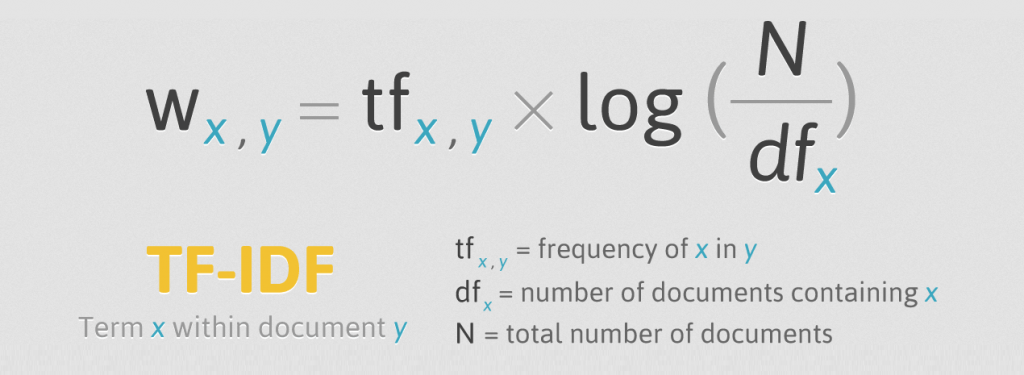

Em outras palavras, para o TF-IDF, quanto mais frequente uma palavra é em seu documento, mais relevante ela será no contexto. Entretanto, isso depende da repetição dela ao longo de todos os documentos que estão sendo analisados.

Por exemplo, suponhamos que estejamos analisando três revistas, cada uma relacionada a um esporte diferente:

- Futebol;
- Vôlei;
- Basquete.

Temos palavras que se repetem ao longo de todos esses documentos, por exemplo, a palavra "esporte" deve aparecer em todas as três revistas, logo, não deve contribuir muito para uma análise.

Porém, palavras que se repetem muito em documentos individuais dizem mais a respeito dele, então a palavra "cesta", por exemplo, que pode se repetir muito na revista sobre basquete, mas não nas outras, tende a se tornar mais importante para o TF-IDF.

Por isso dizemos que a repetição das palavras com relação aos documentos que estão sendo analisados é importante.

Em nosso poema, consideraremos cada estrofe como um documento (mas poderíamos fazer de outras formas também, considerando cada verso como um documento, por exemplo).

In [ ]:
estrofe1= 'no meio do caminho tinha uma pedra tinha uma pedra no meio do caminho tinha uma pedra no meio do caminho tinha uma pedra'

estrofe2 = 'nunca me esquecerei desse acontecimento na vida de minhas retinas tão fatigadas nunca me esquecerei que no meio do caminho tinha uma pedra tinha uma pedra no meio do caminho no meio do caminho tinha uma pedra'

**Implementando o TF-IDF**

Para a implementação de TF-IDF vamos fazer algo similar ao que fizemos com o `BoW` anteriormente:

- Vamos selecionar seus dados e pré-processar seu texto;
- Vamos gerar um vocabulário, ou seja, uma lista com todos os termos do nosso texto.

Como essas duas etapas já foram feitas, não vamos repeti-las. Nosso vocabulário está armazenado na lista `Vocab`.

Desta forma, vamos direto para o último passo:

- Gerar um dicionário de frequência desses termos.

O dicionário será criado a partir de uma função chamada `dicionario_de_contagem`, que retorna a palavra e a quantidade de ocorrências dela.

Esta função recebe como argumentos a lista `Vocab` e o documento "tokenizado", criando um dicionário com as palavras do poema e o número de ocorrências.

In [ ]:
e1_tokens = estrofe1.split()

e2_tokens = estrofe2.split()

In [ ]:
def dicionario_de_contagem(vocabulario, documento):
  '''Recebe uma lista com o vocabulario e uma lista de tokens de um documento.
  Retorna um dicionario com o numero de vezes que cada palavra do vocabulario
  ocorre no documento.'''
  dic = dict.fromkeys(vocabulario, 0)
  for palavra in documento:
    dic[palavra] = dic[palavra] + 1
  return dic

In [ ]:
e1_dic_cont = dicionario_de_contagem(Vocab, e1_tokens)
e2_dic_cont = dicionario_de_contagem(Vocab, e2_tokens)

print(e1_dic_cont,'\n')
print(e2_dic_cont)

{'no': 3, 'meio': 3, 'do': 3, 'caminho': 3, 'tinha': 4, 'uma': 4, 'pedra': 4, 'nunca': 0, 'me': 0, 'esquecerei': 0, 'desse': 0, 'acontecimento': 0, 'na': 0, 'vida': 0, 'de': 0, 'minhas': 0, 'retinas': 0, 'tão': 0, 'fatigadas': 0, 'que': 0} 

{'no': 3, 'meio': 3, 'do': 3, 'caminho': 3, 'tinha': 3, 'uma': 3, 'pedra': 3, 'nunca': 2, 'me': 2, 'esquecerei': 2, 'desse': 1, 'acontecimento': 1, 'na': 1, 'vida': 1, 'de': 1, 'minhas': 1, 'retinas': 1, 'tão': 1, 'fatigadas': 1, 'que': 1}


**TF (Term Frequency)**

Como sua definição diz, esse termo é dado pela divisão da quantidade de vezes que uma palavra aparece em um documento pela quantidade de palavras desse mesmo documento, ou seja, representa com que frequência um termo ocorre em um documento. Percebe-se que o TF é basicamente a implementação de um *BoW* para cada documento.

Então, voltando ao exemplo das revistas, se pegarmos a de futebol, algumas palavras que possam ter um alto índice de TF são as que têm alta relação com o assunto (futebol) como: bola, jogador, gol, entre outros.

Para o código, vamos fazer como na função `dicionario_de_contagem`, porém passando como texto os documentos e ao invés de devolver a frequência, devolver esse valor normalizado, ou seja, dividido pela quantidade de palavras do documento.

In [ ]:
def calculaTF(dic_de_cont, doc):
    tf_dic = {}
    num_palavras_doc = len(doc)
    for palavra, contagem in dic_de_cont.items():
        tf_dic[palavra] = contagem/float(num_palavras_doc)
    return(tf_dic)

In [ ]:
e1_tf_bow = calculaTF(e1_dic_cont, e1_tokens)
e2_tf_bow = calculaTF(e2_dic_cont, e2_tokens)

print(e1_tf_bow)
print(e2_tf_bow)

{'no': 0.125, 'meio': 0.125, 'do': 0.125, 'caminho': 0.125, 'tinha': 0.16666666666666666, 'uma': 0.16666666666666666, 'pedra': 0.16666666666666666, 'nunca': 0.0, 'me': 0.0, 'esquecerei': 0.0, 'desse': 0.0, 'acontecimento': 0.0, 'na': 0.0, 'vida': 0.0, 'de': 0.0, 'minhas': 0.0, 'retinas': 0.0, 'tão': 0.0, 'fatigadas': 0.0, 'que': 0.0}
{'no': 0.08108108108108109, 'meio': 0.08108108108108109, 'do': 0.08108108108108109, 'caminho': 0.08108108108108109, 'tinha': 0.08108108108108109, 'uma': 0.08108108108108109, 'pedra': 0.08108108108108109, 'nunca': 0.05405405405405406, 'me': 0.05405405405405406, 'esquecerei': 0.05405405405405406, 'desse': 0.02702702702702703, 'acontecimento': 0.02702702702702703, 'na': 0.02702702702702703, 'vida': 0.02702702702702703, 'de': 0.02702702702702703, 'minhas': 0.02702702702702703, 'retinas': 0.02702702702702703, 'tão': 0.02702702702702703, 'fatigadas': 0.02702702702702703, 'que': 0.02702702702702703}


In [ ]:
e1_tf_bow

{'no': 0.125,
 'meio': 0.125,
 'do': 0.125,
 'caminho': 0.125,
 'tinha': 0.16666666666666666,
 'uma': 0.16666666666666666,
 'pedra': 0.16666666666666666,
 'nunca': 0.0,
 'me': 0.0,
 'esquecerei': 0.0,
 'desse': 0.0,
 'acontecimento': 0.0,
 'na': 0.0,
 'vida': 0.0,
 'de': 0.0,
 'minhas': 0.0,
 'retinas': 0.0,
 'tão': 0.0,
 'fatigadas': 0.0,
 'que': 0.0}

In [ ]:
e2_tf_bow

{'no': 0.08108108108108109,
 'meio': 0.08108108108108109,
 'do': 0.08108108108108109,
 'caminho': 0.08108108108108109,
 'tinha': 0.08108108108108109,
 'uma': 0.08108108108108109,
 'pedra': 0.08108108108108109,
 'nunca': 0.05405405405405406,
 'me': 0.05405405405405406,
 'esquecerei': 0.05405405405405406,
 'desse': 0.02702702702702703,
 'acontecimento': 0.02702702702702703,
 'na': 0.02702702702702703,
 'vida': 0.02702702702702703,
 'de': 0.02702702702702703,
 'minhas': 0.02702702702702703,
 'retinas': 0.02702702702702703,
 'tão': 0.02702702702702703,
 'fatigadas': 0.02702702702702703,
 'que': 0.02702702702702703}

**IDF (*Inverse Document Frequency*)**

Mais uma vez em nosso exemplo das revistas de futebol, vôlei e basquete, apenas a TF  ainda vai dar maior ênfase à palavra "esporte", que se repetirá mais vezes nas três revistas, do que à palavra "cesta".

É exatamente aí que entra o IDF: uma medida, originalmente proposta pela cientista [Karen Spärck Jones](https://www.staff.city.ac.uk/~sbrp622/idf.html), para dar maior peso a palavras que ocorrem em menos documentos (no exemplo, estamos considerando cada revista como um documento).

Dessa forma, esse peso será inversamente proporcional ao número de documentos em que uma palavra aparece e por isso o nome "inverso da frequência nos documentos".

Mas como calcular essa medida? Há várias formas, algumas mais convenientes dependendo da aplicação do que outras. O necessário é apenas que seja uma função inversamente proporcional à frequência nos documentos, ou seja, decrescente em relação a ela. A função mais comum é a seguinte, que já apresentamos:


$idf_t=log(\frac{N}{df_t}$)

Sendo:

- $N$ o número de documentos no corpus;
- $t$ um termo do corpus;
- $df_t$ o número de documentos em que o termo aparece.

Passamos então essa medida para a escala logarítimica, o que reduz a sua grandeza, sendo útil, principalmente quando trabalhamos com os corpus tradicionalmente grandes em PLN.

Vamos ver a função e a curva resultante.



In [ ]:
import math

def calculaIDF(lista_de_docs):
    idf_dic = {}
    N = len(lista_de_docs)

    for palavra in lista_de_docs[0]:
        num_docs_aparece = 0
        for doc in lista_de_docs:
            if doc[palavra]>0:
                num_docs_aparece += 1

        idf_dic[palavra] = math.log10(N / (num_docs_aparece))

    return (idf_dic)

In [ ]:
estrofes_idf = calculaIDF([e1_dic_cont, e2_dic_cont])

In [ ]:
estrofes_idf

{'no': 0.0,
 'meio': 0.0,
 'do': 0.0,
 'caminho': 0.0,
 'tinha': 0.0,
 'uma': 0.0,
 'pedra': 0.0,
 'nunca': 0.3010299956639812,
 'me': 0.3010299956639812,
 'esquecerei': 0.3010299956639812,
 'desse': 0.3010299956639812,
 'acontecimento': 0.3010299956639812,
 'na': 0.3010299956639812,
 'vida': 0.3010299956639812,
 'de': 0.3010299956639812,
 'minhas': 0.3010299956639812,
 'retinas': 0.3010299956639812,
 'tão': 0.3010299956639812,
 'fatigadas': 0.3010299956639812,
 'que': 0.3010299956639812}

**Gráfico**

Quanto maior $df_t$, menor será $N/df_t$, logo, temos uma função decrescente.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

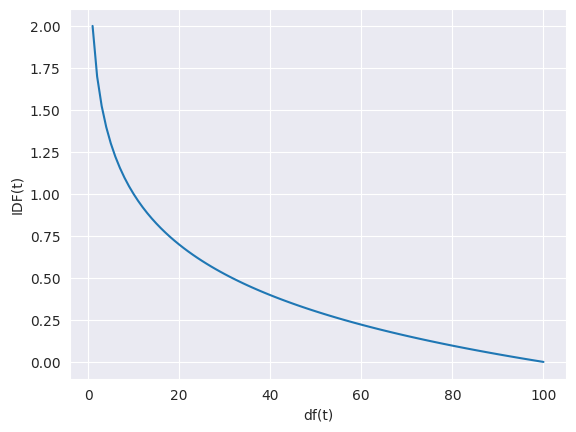

In [ ]:
x = np.linspace(1,100,100)
y = np.log10(100/x)

# Plotando

sns.set_style('darkgrid')
fig, ax = plt.subplots()

ax.plot(x,y)
ax.set_xlabel('df(t)')
ax.set_ylabel('IDF(t)')

plt.show()

**Juntando TF-IDF**

Para obter a pontuação TF-IDF, basta então multiplicar essas duas medidas.
Assim, quanto maior a TF e a IDF, maior a pontuação obtida, ou seja, as palavras consideradas mais relevantes serão aquelas que aparecem muito em um documento, mas pouco em outros.

In [ ]:
def calculaTFIDF(tf_bow, idfs):
    tfidf = {}

    for palavra in tf_bow:
        tf = tf_bow[palavra]
        idf = idfs[palavra]
        tfidf[palavra] = tf*idf

    return(tfidf)

In [ ]:
e1_tfidf = calculaTFIDF(e1_tf_bow, estrofes_idf)
e2_tfidf = calculaTFIDF(e2_tf_bow, estrofes_idf)

In [ ]:
e1_tfidf

{'no': 0.0,
 'meio': 0.0,
 'do': 0.0,
 'caminho': 0.0,
 'tinha': 0.0,
 'uma': 0.0,
 'pedra': 0.0,
 'nunca': 0.0,
 'me': 0.0,
 'esquecerei': 0.0,
 'desse': 0.0,
 'acontecimento': 0.0,
 'na': 0.0,
 'vida': 0.0,
 'de': 0.0,
 'minhas': 0.0,
 'retinas': 0.0,
 'tão': 0.0,
 'fatigadas': 0.0,
 'que': 0.0}

In [ ]:
e2_tfidf

{'no': 0.0,
 'meio': 0.0,
 'do': 0.0,
 'caminho': 0.0,
 'tinha': 0.0,
 'uma': 0.0,
 'pedra': 0.0,
 'nunca': 0.0162718916575125,
 'me': 0.0162718916575125,
 'esquecerei': 0.0162718916575125,
 'desse': 0.00813594582875625,
 'acontecimento': 0.00813594582875625,
 'na': 0.00813594582875625,
 'vida': 0.00813594582875625,
 'de': 0.00813594582875625,
 'minhas': 0.00813594582875625,
 'retinas': 0.00813594582875625,
 'tão': 0.00813594582875625,
 'fatigadas': 0.00813594582875625,
 'que': 0.00813594582875625}

### Resultado

In [ ]:
import pandas as pd

tfidf_dataframe = pd.DataFrame([e1_tfidf, e2_tfidf])
tfidf_dataframe["Estrofes"] = ['estrofe 1', 'estrofe 2']
tfidf_dataframe.reset_index(inplace=True)
#tfidf_dataframe.drop('index', 1, inplace=True)
tfidf_dataframe.set_index('Estrofes', inplace=True)
tfidf_dataframe.index.name = None

tfidf_dataframe

,index,no,meio,do,caminho,tinha,uma,pedra,nunca,me,...,desse,acontecimento,na,vida,de,minhas,retinas,tão,fatigadas,que
estrofe 1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
estrofe 2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.016272,0.016272,...,0.008136,0.008136,0.008136,0.008136,0.008136,0.008136,0.008136,0.008136,0.008136,0.008136


Veja que tanto os termos que não aparecem na estrofe como os que aparecem em todas as estrofes ficam com pontuação `0`, porque se o termo aparece em todas as estrofes, `df(t)=N`, e seu valor de `idf` será `log(N/N)=log1=0`.

Por isso, na primeira estrofe, todas as pontuações são `0`.

## **Tarefa**

Vamos trabalhar juntando os códigos da semana passada e desta semana.

A tarefa consiste em capturar as músicas de uma banda a escolha de vocês, utilizando o código do Colab enterior, até o pré-processamento, incluindo-o.

Sugestão: atualize o dataframe com as letras originais das músicas com as letras pré-processadas. O nome das músicas será nevcessário na prócima etapa.

A partir do conteúdo das músicas, defina um vocabulário, e calcule a métrica TF-IDF para todo este vocabulário. Considere cada música como um documento. Apresente o resultado em uma tabela bem formatada.
